# Préparation des données

In [179]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
colors = sns.color_palette("crest", 8)
cmap_colors = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
plt.rcParams["figure.figsize"] = (10,6)
pastel_palette = [
    "#FFB6C1", "#BFD8B8", "#A2D2FF", "#FFD700",
    "#F8C8DC", "#D1B2FF", "#E6E6FA", "#FFE4E1"
]

# Extend or repeat the palette if there are more departments than colors


In [132]:
dir_path = '/Users/RachidAJ/Desktop/Statistics Projects/instacart-market-basket-analysis'
order_products_train = pd.read_csv(f'{dir_path}/order_products__train.csv')
order_products_prior = pd.read_csv(f'{dir_path}/order_products__prior.csv')
orders      = pd.read_csv(f'{dir_path}/orders.csv')
products    = pd.read_csv(f'{dir_path}/products.csv')
aisles      = pd.read_csv(f'{dir_path}/aisles.csv')
departments = pd.read_csv(f'{dir_path}/departments.csv')

def reduce_mem_usage(train_data):
    start_mem = train_data.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in train_data.columns:
        col_type = train_data[col].dtype
        
        if col_type not in [object, 'category']:
            c_min = train_data[col].min()
            c_max = train_data[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    train_data[col] = train_data[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    train_data[col] = train_data[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    train_data[col] = train_data[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    train_data[col] = train_data[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    train_data[col] = train_data[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    train_data[col] = train_data[col].astype(np.float32)
                else:
                    train_data[col] = train_data[col].astype(np.float64)
        else:
            train_data[col] = train_data[col].astype('category')
    end_mem = train_data.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return train_data

In [133]:
order_products_train=reduce_mem_usage(order_products_train)
order_products_prior=reduce_mem_usage(order_products_prior)
orders=reduce_mem_usage(orders)
products=reduce_mem_usage(products)
aisles=reduce_mem_usage(aisles)
departments=reduce_mem_usage(departments)
order_products_train.head()

Memory usage of dataframe is 42.26 MB
Memory usage after optimization is: 13.20 MB
Decreased by 68.7%
Memory usage of dataframe is 989.82 MB
Memory usage after optimization is: 340.25 MB
Decreased by 65.6%
Memory usage of dataframe is 182.71 MB
Memory usage after optimization is: 45.68 MB
Decreased by 75.0%
Memory usage of dataframe is 1.52 MB
Memory usage after optimization is: 1.91 MB
Decreased by -25.8%
Memory usage of dataframe is 0.00 MB
Memory usage after optimization is: 0.01 MB
Decreased by -159.6%
Memory usage of dataframe is 0.00 MB
Memory usage after optimization is: 0.00 MB
Decreased by -91.9%


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [134]:
orders.head()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [135]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [136]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [137]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [138]:
full_products = products.copy()
full_products = pd.merge(full_products, aisles,               on='aisle_id',      how='left')
full_products = pd.merge(full_products, departments,          on='department_id', how='left')
order_products_train = pd.merge(order_products_train, orders, on='order_id',      how='left')
order_products_prior = pd.merge(order_products_prior, orders, on='order_id',      how='left')
train         = pd.merge(order_products_train, full_products, on='product_id',    how='left')
test          = pd.merge(order_products_prior, full_products, on='product_id',    how='left')

In [139]:
full_products.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [140]:
del order_products_train
del order_products_prior
train.head()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [141]:
test.head()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [142]:
print(f'train.shape: {train.shape}')
print(f'test.shape : {test.shape}')

train.shape: (1384617, 15)
test.shape : (32434489, 15)


In [143]:
train.dtypes

order_id                     int32
product_id                   int32
add_to_cart_order             int8
reordered                     int8
user_id                      int32
eval_set                  category
order_number                  int8
order_dow                     int8
order_hour_of_day             int8
days_since_prior_order     float16
product_name              category
aisle_id                     int16
department_id                 int8
aisle                     category
department                category
dtype: object

In [144]:
data = pd.concat([train, test], ignore_index=True)
colors = (pastel_palette * (len(data) // len(pastel_palette) + 1))[:len(data)]
del train
del test

In [145]:
data.describe()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,31741038.0,3.381911e+07,3.381911e+07
mean,1.710566e+06,2.557551e+04,8.367738e+00,5.900617e-01,1.029444e+05,1.713998e+01,2.737285e+00,1.343123e+01,NaN,7.121799e+01,9.918544e+00
std,9.874008e+05,1.409770e+04,7.139540e+00,4.918220e-01,5.946733e+04,1.749829e+01,2.093296e+00,4.246149e+00,0.0,3.819898e+01,6.281655e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e+00,1.000000e+00
25%,8.554130e+05,1.351900e+04,3.000000e+00,0.000000e+00,5.143500e+04,5.000000e+00,1.000000e+00,1.000000e+01,5.0,3.100000e+01,4.000000e+00
50%,1.710660e+06,2.525600e+04,6.000000e+00,1.000000e+00,1.026260e+05,1.100000e+01,3.000000e+00,1.300000e+01,8.0,8.300000e+01,9.000000e+00
75%,2.565587e+06,3.793500e+04,1.100000e+01,1.000000e+00,1.544120e+05,2.400000e+01,5.000000e+00,1.600000e+01,15.0,1.070000e+02,1.600000e+01
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,30.0,1.340000e+02,2.100000e+01


In [146]:
print(data.isnull().sum())


order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64


### Description des colonnes :  
* order_id : Un identifiant unique pour chaque commande.  
* user_id : L'ID de l'utilisateur ayant passé la commande.  
* eval_set : Indique si la commande appartient à :  
  - "prior" : Commandes passées utilisées pour l'entraînement.  
  - "train" : Commandes utilisées pour entraîner le modèle à prédire les articles re-commandés.  
  - "test" : Commandes pour lesquelles il faut prédire quels articles ont été re-commandés.  
* order_number : Le numéro de séquence de la commande pour un utilisateur donné (première commande = 1, deuxième commande = 2, etc.).  
* order_dow : Le jour de la semaine où la commande a été passée (0 = dimanche, 1 = lundi, etc.).  
* order_hour_of_day : L'heure de la journée (0-23) à laquelle la commande a été passée.  
* days_since_prior_order : Le nombre de jours écoulés depuis la commande précédente de l'utilisateur. (Vide pour la première commande.). C'est la raison pour laquelle on a des NaN dans la partie days_since_prior_order

# Statistiques Descriptives

In [147]:
reordered_products= data.loc[:, ['department', 'reordered']]
prods = reordered_products.groupby('department', as_index=False)['reordered'].mean()
prods.rename(columns={'reordered': 'reorder_rate'}, inplace=True)
prods.head()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/2698034802.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prods = reordered_products.groupby('department', as_index=False)['reordered'].mean()


,department,reorder_rate
0,alcohol,0.571221
1,babies,0.577680
2,bakery,0.628381
3,beverages,0.653651
4,breakfast,0.561351


/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3003963029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="reorder_rate", y="department", data=merged_sorted, palette=colors,order=merged_sorted['department'])
/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3003963029.py:5: UserWarning: The palette list has more values (33819106) than needed (21), which may not be intended.
  sns.barplot(x="reorder_rate", y="department", data=merged_sorted, palette=colors,order=merged_sorted['department'])


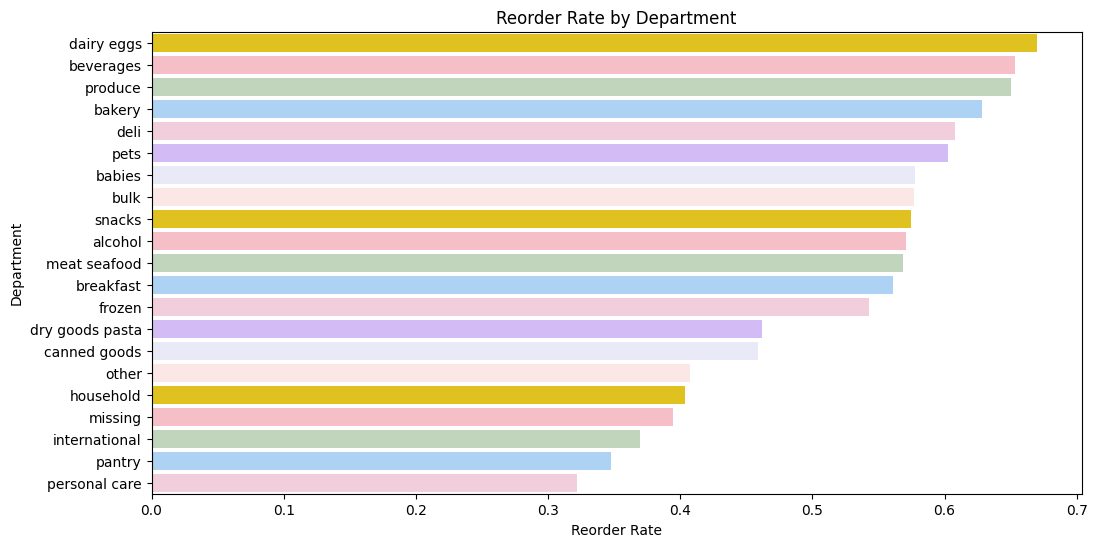

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_sorted = prods.sort_values(by="reorder_rate", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="reorder_rate", y="department", data=merged_sorted, palette=colors,order=merged_sorted['department'])
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.title("Reorder Rate by Department")
plt.show()

Le but du projet est de prédire les produits qui vont être souhaités ou achetés par un client, néanmoins le nombre des produits est de l'ordre de 47000, nous avons réduit notre plan de travail initialement au niveau des rayons (Department) puis des allées (aisles). Ce graphe illustre la moyenne du nombre de fois que les clients ont repassé commande dans un rayon spécifique.

In [149]:
reordered_products= data.loc[:, ['aisle', 'reordered','department']]
prods = reordered_products.groupby(['aisle', 'department'], as_index=False)['reordered'].mean()
prods.rename(columns={'reordered': 'reorder_rate'}, inplace=True)
prods.head()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/359956355.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prods = reordered_products.groupby(['aisle', 'department'], as_index=False)['reordered'].mean()


,aisle,department,reorder_rate
0,air fresheners candles,alcohol,NaN
1,air fresheners candles,babies,NaN
2,air fresheners candles,bakery,NaN
3,air fresheners candles,beverages,NaN
4,air fresheners candles,breakfast,NaN


/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/2116482214.py:6: UserWarning: The palette list has more values (33819106) than needed (21), which may not be intended.
  sns.barplot(x="reorder_rate", y="aisle", hue="department", data=merged_sorted, dodge=False, palette=colors,order=merged_sorted['aisle'])


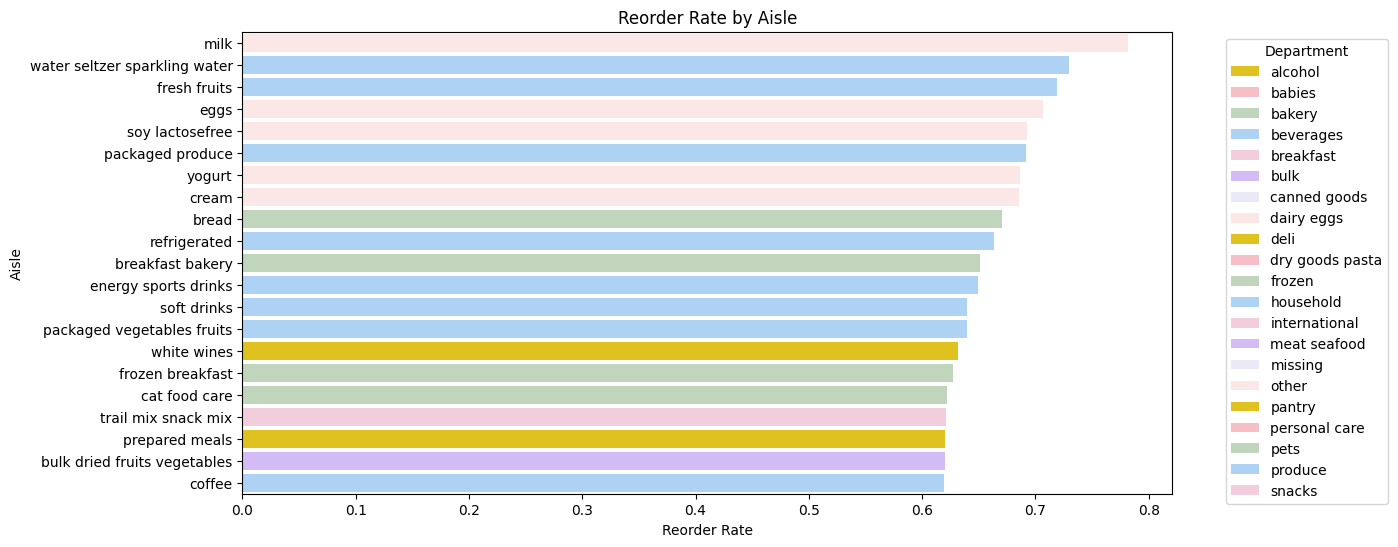

,aisle,department,reorder_rate
1750,milk,dairy eggs,0.781812
2754,water seltzer sparkling water,beverages,0.729930
1069,fresh fruits,produce,0.718823
868,eggs,dairy eggs,0.706359
2506,soy lactosefree,dairy eggs,0.692361
2035,packaged produce,produce,0.691977
2800,yogurt,dairy eggs,0.686501
700,cream,dairy eggs,0.685184
233,bread,bakery,0.670552
2313,refrigerated,beverages,0.663006


In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_sorted = prods.sort_values(by="reorder_rate", ascending=False)
merged_sorted=merged_sorted[:21]
plt.figure(figsize=(12, 6))
sns.barplot(x="reorder_rate", y="aisle", hue="department", data=merged_sorted, dodge=False, palette=colors,order=merged_sorted['aisle'])
plt.xlabel("Reorder Rate")
plt.ylabel("Aisle")
plt.title("Reorder Rate by Aisle")
plt.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")  # Moves legend outside for clarity
plt.show()
merged_sorted[:10]

Ce graphe illustre la moyenne du nombre de fois que les clients ont repassé commande dans une allée spécifique.

In [151]:
purchased_products= data.loc[:, ['aisle', 'order_id','department']]
prods = purchased_products.groupby(['aisle', 'department'], as_index=False)['order_id'].count()
prods.rename(columns={'order_id': 'Count'}, inplace=True)
prods.head()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/2291231631.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prods = purchased_products.groupby(['aisle', 'department'], as_index=False)['order_id'].count()


,aisle,department,Count
0,air fresheners candles,alcohol,0
1,air fresheners candles,babies,0
2,air fresheners candles,bakery,0
3,air fresheners candles,beverages,0
4,air fresheners candles,breakfast,0


/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/39666934.py:5: UserWarning: The palette list has more values (33819106) than needed (21), which may not be intended.
  sns.barplot(x="Count", y="aisle", hue="department", data=merged_sorted, dodge=False, palette=colors,order=merged_sorted['aisle'])


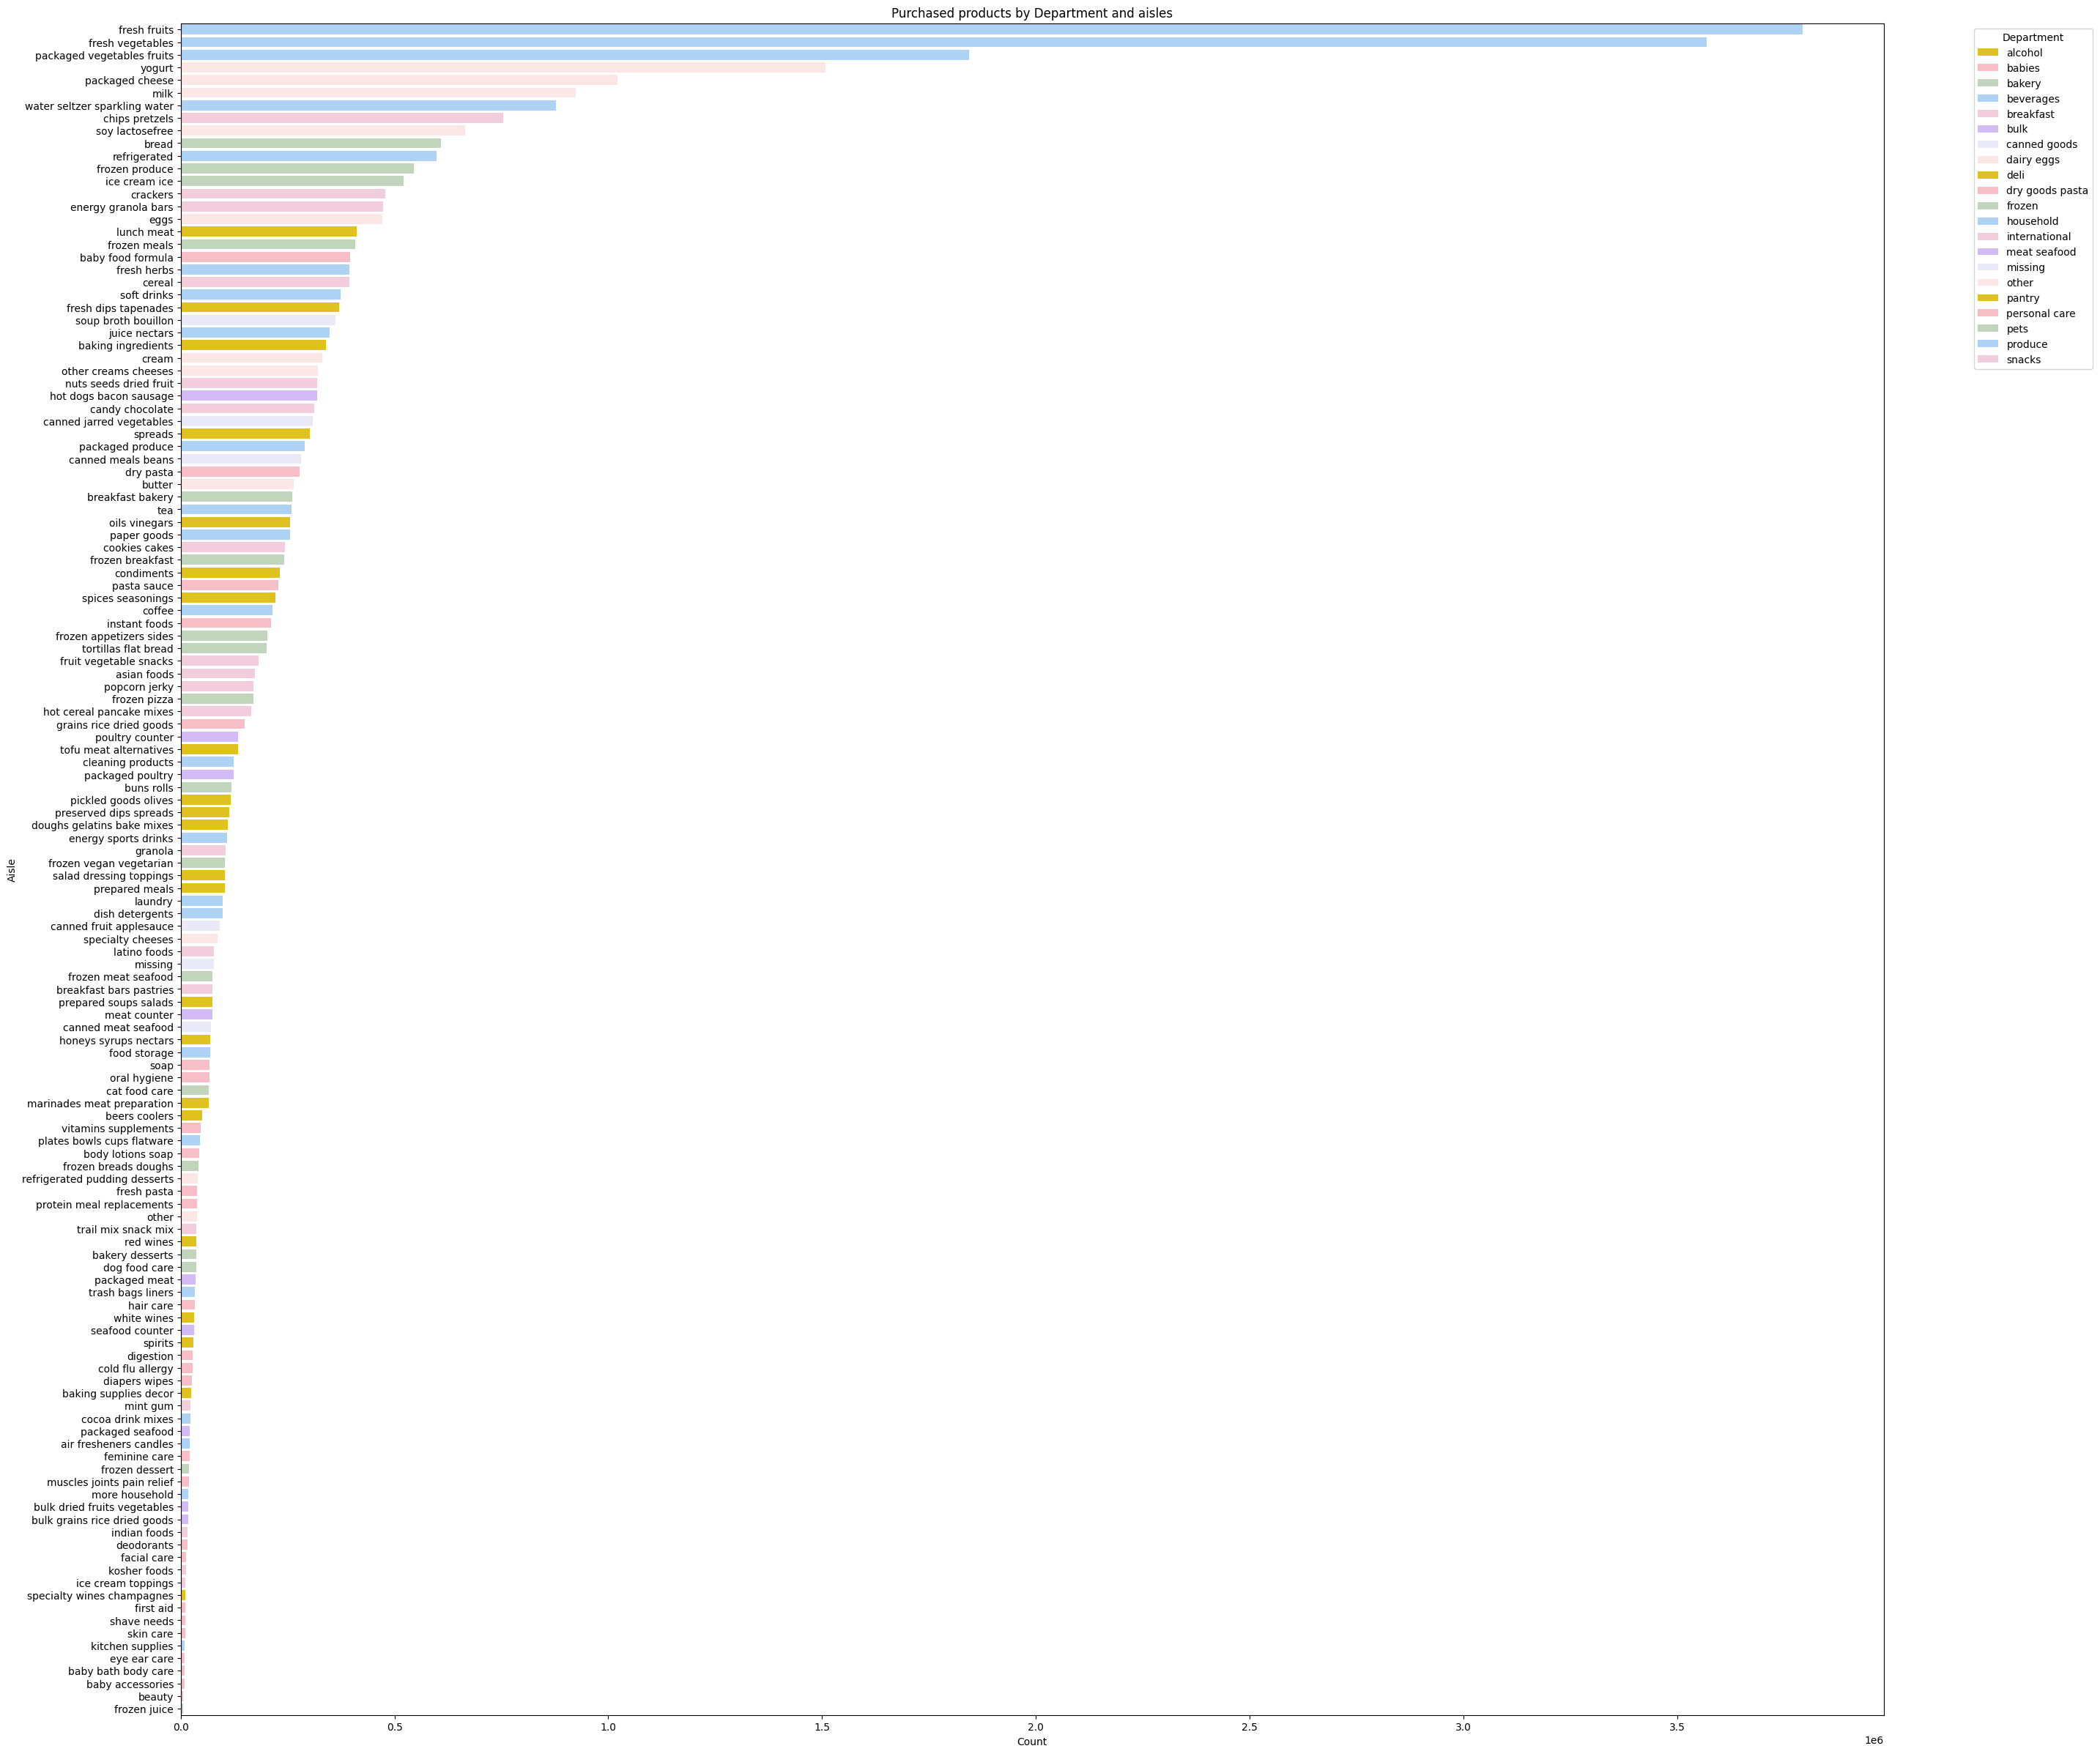

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_sorted = prods.sort_values(by="Count", ascending=False)
plt.figure(figsize=(30, 30))
sns.barplot(x="Count", y="aisle", hue="department", data=merged_sorted, dodge=False, palette=colors,order=merged_sorted['aisle'])
plt.xlabel("Count")
plt.ylabel("Aisle")
plt.title("Purchased products by Department and aisles")
plt.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")  # Moves legend outside for clarity
plt.show()

Ce graphe illustre les allées dont les produits sont les plus au moins commandés

In [153]:
frequency_data = data.loc[:, ['user_id', 'days_since_prior_order']]
frequency_data = frequency_data.groupby('user_id', as_index=False)['days_since_prior_order'].mean()
frequency_data.describe()

,user_id,days_since_prior_order
count,206209.000000,206209.000000
mean,103105.000000,15.631328
std,59527.555167,7.090661
min,1.000000,0.000000
25%,51553.000000,9.809524
50%,103105.000000,15.000000
75%,154657.000000,20.916666
max,206209.000000,30.000000


In [154]:
data['days_since_prior_order'].fillna(-1, inplace=True) #Remplissage des NaN par la valeur -1 

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3594209131.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['days_since_prior_order'].fillna(-1, inplace=True) #Remplissage des NaN par la valeur -1


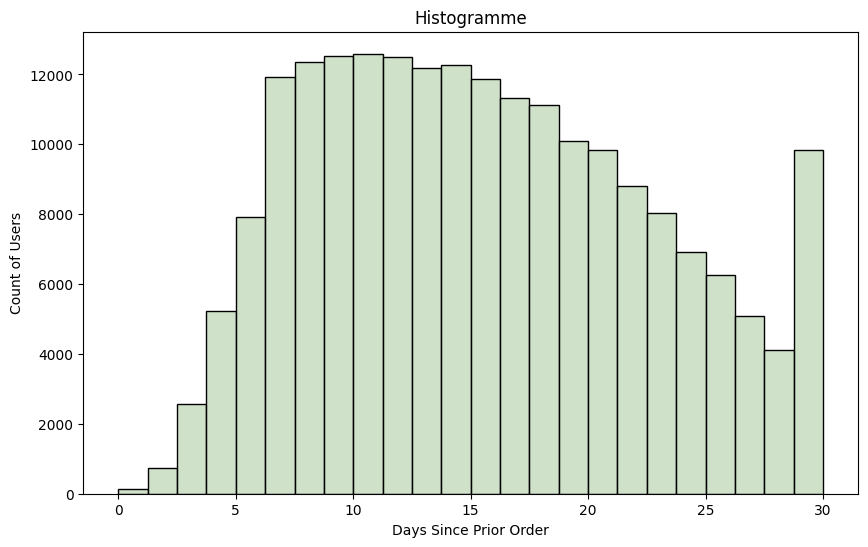

In [155]:
sns.histplot(frequency_data['days_since_prior_order'], bins=24, color="#BFD8B8")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Count of Users")
plt.title("Histogramme")
plt.show()

Les statistiques de base concernant la fréquence d'achat des 

In [156]:
hour_data = data.loc[:, ['order_id', 'order_hour_of_day']]
day_data = data.loc[:, ['order_id', 'order_dow']]
hours = hour_data.groupby('order_id', as_index=False)['order_hour_of_day'].mean()
days=day_data.groupby('order_id', as_index=False)['order_dow'].mean()

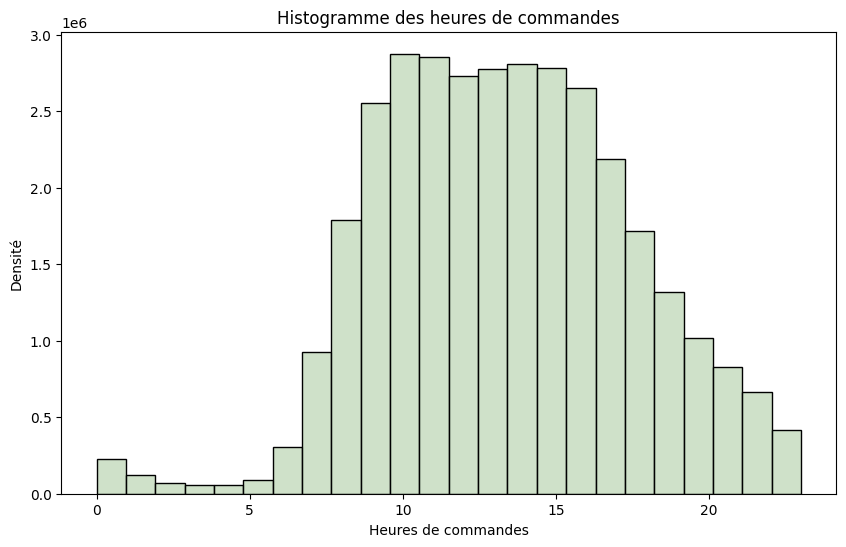

In [157]:
sns.histplot(hour_data['order_hour_of_day'], bins=24, color="#BFD8B8")
plt.xlabel("Heures de commandes")
plt.ylabel("Densité")
plt.title("Histogramme des heures de commandes")
plt.show()

Ce graphe illustre la répartition des commandes tout au long de la journée

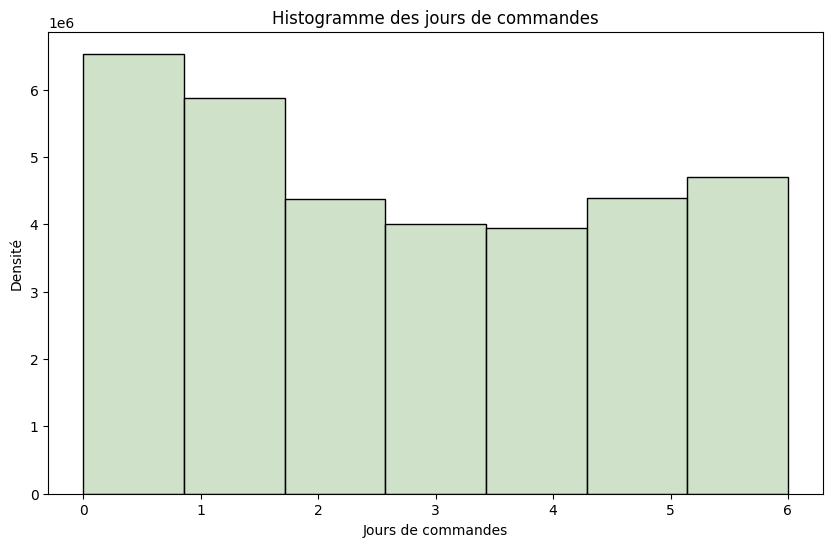

In [158]:
sns.histplot(day_data['order_dow'], bins=7, color="#BFD8B8")
plt.xlabel("Jours de commandes")
plt.ylabel("Densité")
plt.title("Histogramme des jours de commandes")
plt.show()

Ce graphe illustre la répartition des commandes tout au long de la semaine

Ce graphe illustre la répartition des commandes tout au long de la semaine

In [159]:
data['days_since_prior_order'].fillna(-1, inplace=True) #Remplissage des NaN par la valeur -1 

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3594209131.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['days_since_prior_order'].fillna(-1, inplace=True) #Remplissage des NaN par la valeur -1


/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/1009271550.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['first-time ordered products', 'reordered'])


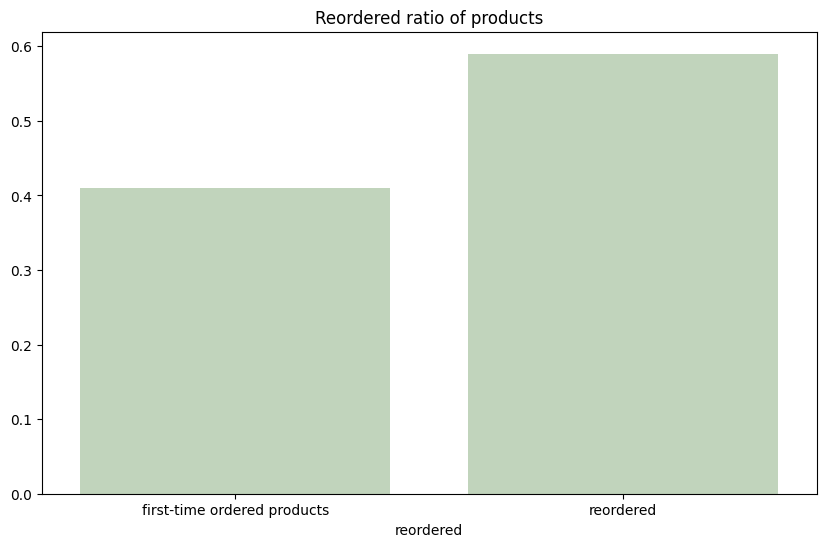

In [160]:
total_prod_count = data.shape[0]
reorder_ratio = data['reordered'].value_counts()/total_prod_count
ax = sns.barplot(x=reorder_ratio.index, y=reorder_ratio.values,color="#BFD8B8")
ax.set_xticklabels(['first-time ordered products', 'reordered'])
plt.title('Reordered ratio of products')
plt.show()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3791421608.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['atleast one reordered', 'no-reordered products'])


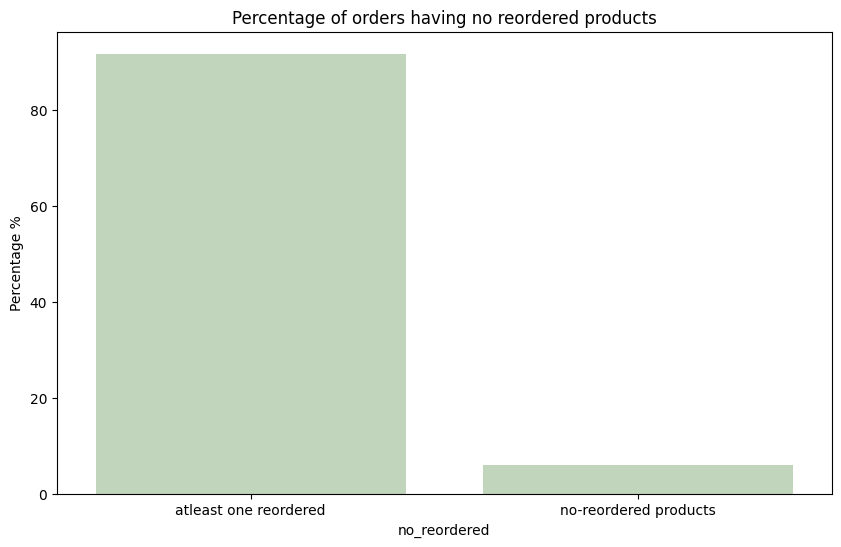

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3791421608.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['not purely all products are reordered', 'all products are reordered'])


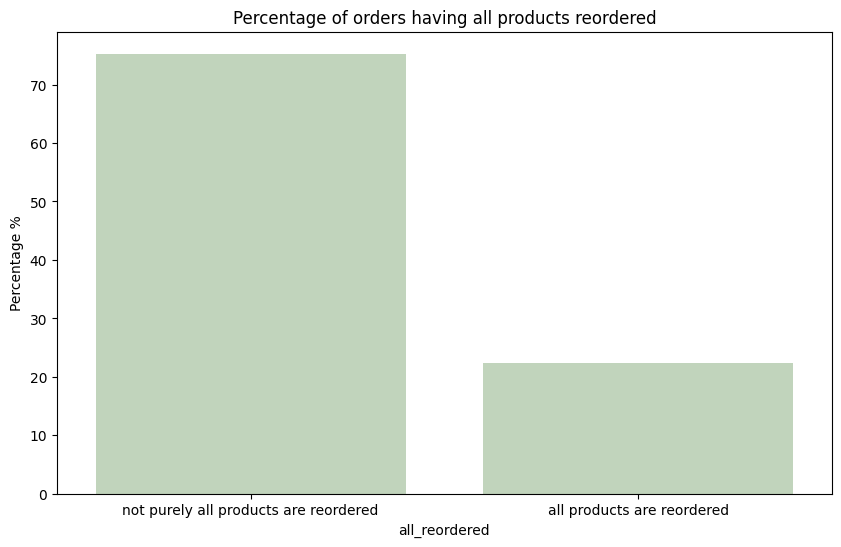

In [161]:
groupeddf = data.groupby(['order_id']).agg({'reordered':'mean', 'order_number':'first'}).reset_index().rename(columns={'reordered':'reordered_ratio'})
groupeddf['no_reordered'] = groupeddf['reordered_ratio'] == 0
groupeddf['all_reordered'] = groupeddf['reordered_ratio'] == 1.0

# Count of non-first orders
non_first_orders_Mask = orders.order_number != 1
non_first_orders_count = np.sum(non_first_orders_Mask)

# Ratio of non-first orders containing no previously ordered products vs containing at least one previously ordered products
groupeddf = groupeddf[groupeddf.order_number != 1]
groupeddf['no_reordered'] = groupeddf['reordered_ratio'] == 0
no_reordered_count = groupeddf['no_reordered'].value_counts()/non_first_orders_count * 100
ax = sns.barplot(x=no_reordered_count.index, y=no_reordered_count.values,color="#BFD8B8")
ax.set_xticklabels(['atleast one reordered', 'no-reordered products'])
plt.title('Percentage of orders having no reordered products')
plt.ylabel('Percentage %')
plt.show()

groupeddf['all_reordered'] = groupeddf['reordered_ratio'] == 1.0
all_reordered_count = groupeddf['all_reordered'].value_counts()/non_first_orders_count * 100
ax = sns.barplot(x=all_reordered_count.index, y=all_reordered_count.values,color="#BFD8B8")
ax.set_xticklabels(['not purely all products are reordered', 'all products are reordered'])
plt.title('Percentage of orders having all products reordered')
plt.ylabel('Percentage %')
plt.show()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/4112399840.py:8: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(nbins=20)


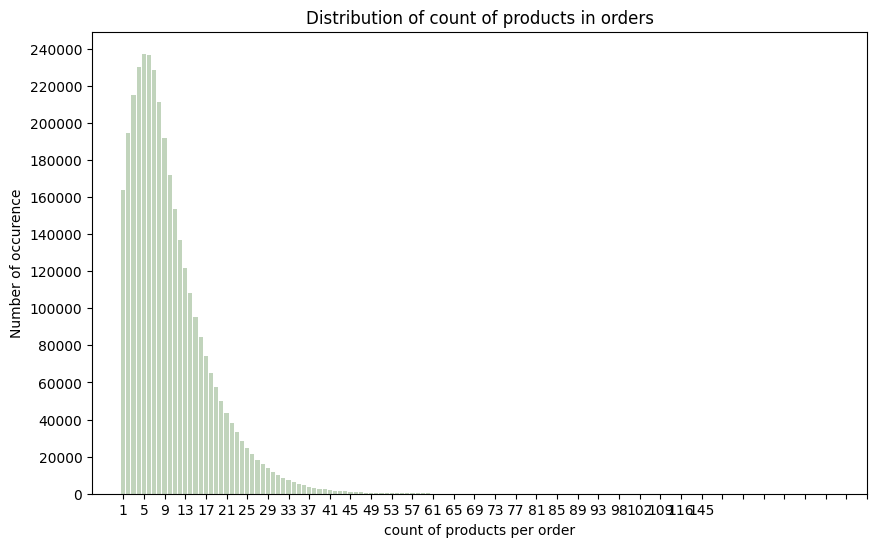

In [162]:
# Ploting a histogram for the # of products in an order
count_of_products = data.groupby(['order_id'], as_index=False)['product_id'].count()
count_of_products['count_of_products'] = count_of_products['product_id']
sns.countplot(x='count_of_products', data=count_of_products,color="#BFD8B8")
plt.xlabel('count of products per order')
plt.ylabel('Number of occurence')
plt.title('Distribution of count of products in orders')
plt.locator_params(nbins=20)
max_x = count_of_products['count_of_products'].max()
plt.xticks(ticks=range(0, max_x + 1, 4))
plt.show()

del count_of_products

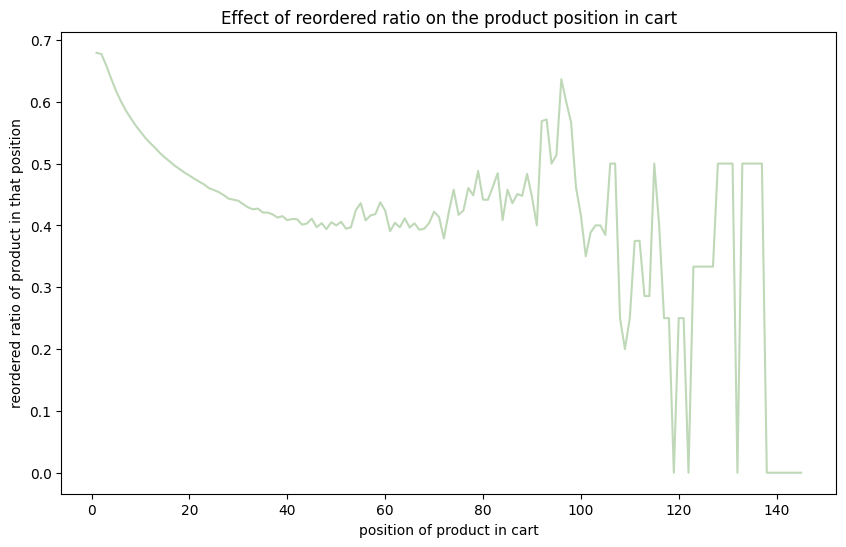

In [163]:
groupeddf = data.groupby(['add_to_cart_order']).agg({'reordered':'mean'}).rename(columns={'reordered':'reordered_ratio'}).reset_index()
sns.lineplot(x=groupeddf['add_to_cart_order'], y=groupeddf['reordered_ratio'],color="#BFD8B8")
plt.title('Effect of reordered ratio on the product position in cart')
plt.xlabel('position of product in cart')
plt.ylabel('reordered ratio of product in that position')
plt.show()


In [164]:
from matplotlib.colors import LinearSegmentedColormap
compatible_colors = ['#BFD8B8', '#A2D2FF', '#FFD700', '#D1B2FF']
custom_cmap = LinearSegmentedColormap.from_list("compatible_palette", compatible_colors)

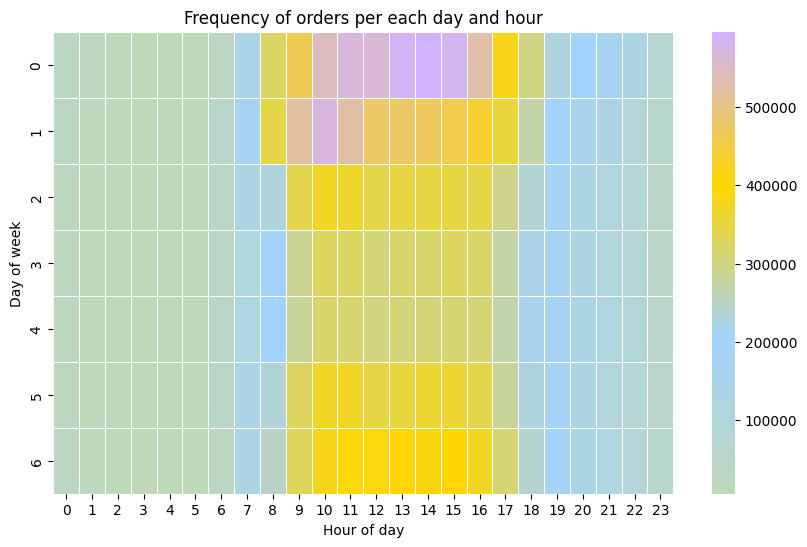

In [165]:
groupeddf = data.groupby(['order_dow', 'order_hour_of_day'])['order_id'].agg('count').reset_index().rename(columns={'order_id':'orders_count'})
heatmap_data = groupeddf.pivot(index='order_dow', columns='order_hour_of_day', values='orders_count')
ax = sns.heatmap(data=heatmap_data, cmap=custom_cmap, linewidths=.5)
plt.title('Frequency of orders per each day and hour')
plt.ylabel('Day of week')
plt.xlabel('Hour of day')
plt.show()

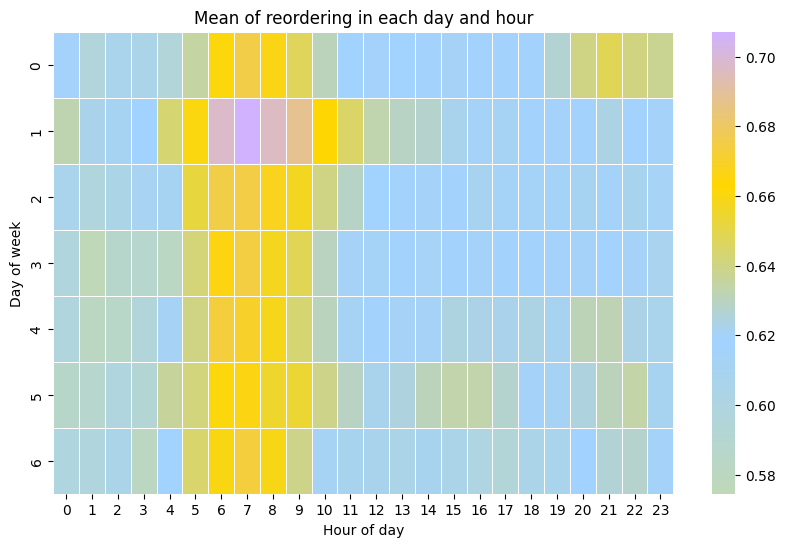

In [166]:
# Heatmap on the propability of non-new users to reorder for each day each hour
non_first_orders = data['order_number'] != 1
groupeddf = data[non_first_orders].groupby(['order_dow', 'order_hour_of_day']).agg({'reordered':'mean'}).reset_index().rename(columns={'reordered':'reordered_ratio'})
heatmap_data = groupeddf.pivot(index='order_dow', columns='order_hour_of_day', values='reordered_ratio')
ax = sns.heatmap(data=heatmap_data, cmap=custom_cmap, linewidths=.5)
plt.title('Mean of reordering in each day and hour')
plt.ylabel('Day of week')
plt.xlabel('Hour of day')
plt.show()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/347018239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_2 = prod_dept.groupby(['department']).agg({'product_id':'count'}).reset_index().rename(columns={'product_id':'products_count'})


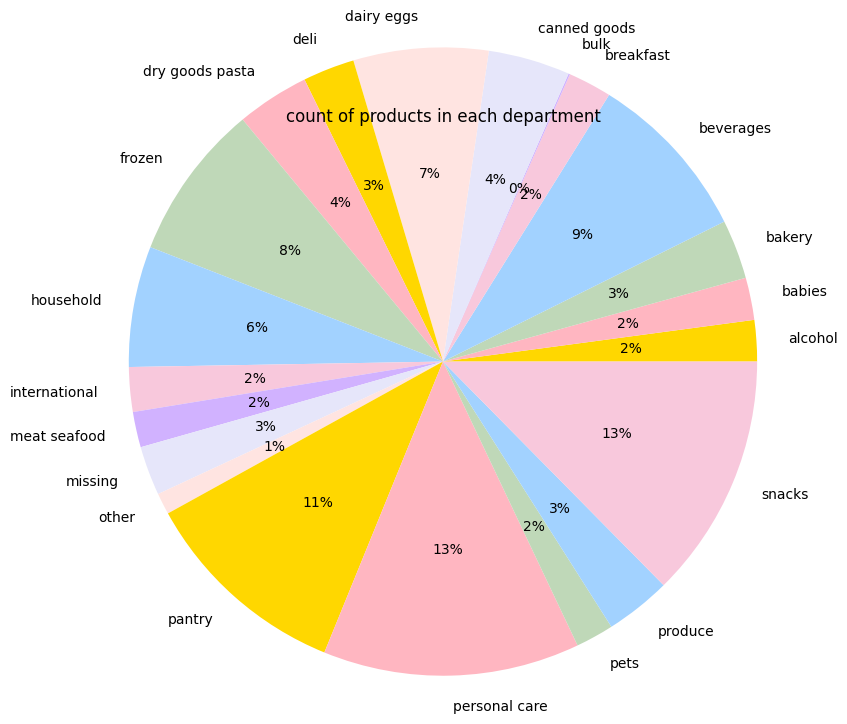

In [167]:

prod_dept = products.merge(departments, on='department_id', how='left')
data_2 = prod_dept.groupby(['department']).agg({'product_id':'count'}).reset_index().rename(columns={'product_id':'products_count'})
plt.pie(data_2['products_count'], labels = data_2['department'], autopct='%.0f%%', radius=1.7,colors=colors)
plt.title('count of products in each department')
plt.show()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/3705387206.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupeddf = data.groupby(['department'], as_index=False).count().rename(columns={'department_id':'count_of_ordered_prods'})


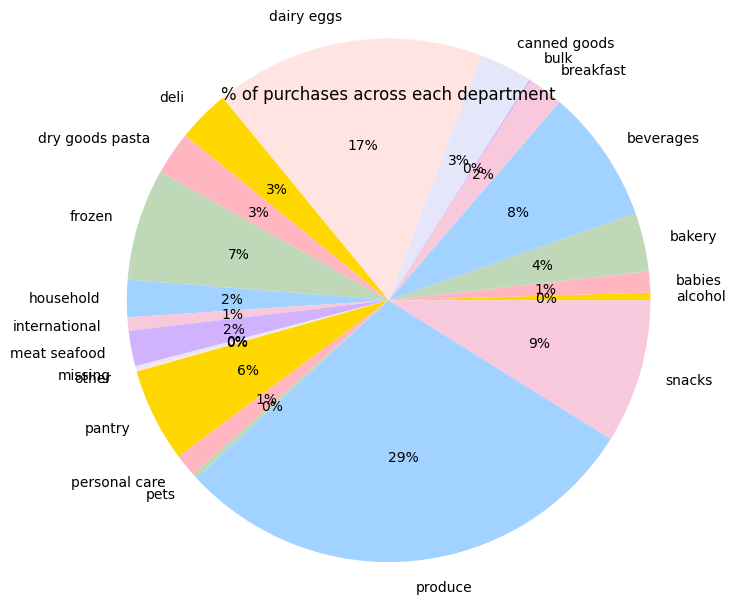

In [168]:
# From All ordered products, the count of contribution of each department
# Group by the count of ordering from a department
total_ordered_products = data.shape[0]
groupeddf = data.groupby(['department'], as_index=False).count().rename(columns={'department_id':'count_of_ordered_prods'})

fig = plt.figure(figsize = (20, 5))
plt.pie(groupeddf['count_of_ordered_prods'], labels = groupeddf['department'], autopct='%.0f%%', radius=1.7, colors=colors)
plt.title('% of purchases across each department')
plt.show()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/254089752.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupeddf = data.groupby(['product_name'], as_index=False).agg({'product_id':'count'}).rename(columns={'product_id':'count_of_ordered_prods'})


<Figure size 2000x500 with 0 Axes>

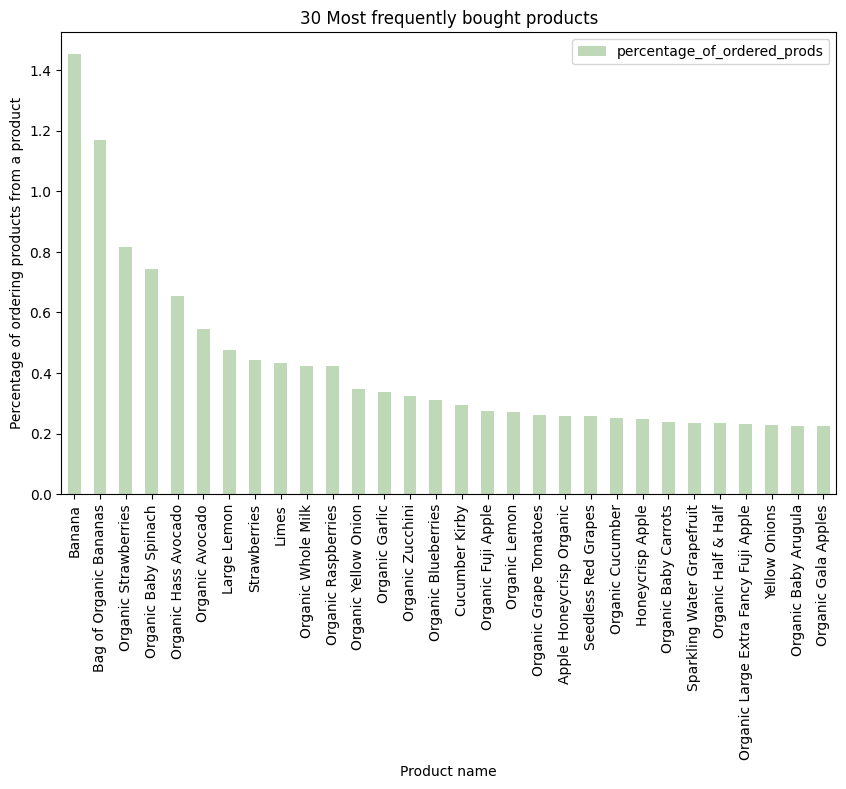

In [169]:
total_ordered_products = data.shape[0]
groupeddf = data.groupby(['product_name'], as_index=False).agg({'product_id':'count'}).rename(columns={'product_id':'count_of_ordered_prods'})
groupeddf['percentage_of_ordered_prods'] = groupeddf['count_of_ordered_prods']/total_ordered_products*100
groupeddf = groupeddf.sort_values(by=['count_of_ordered_prods'], ascending=False)
fig = plt.figure(figsize = (20, 5))
groupeddf.iloc[:30].plot.bar(x='product_name', y='percentage_of_ordered_prods',color="#BFD8B8")
plt.ylabel('Percentage of ordering products from a product')
plt.xlabel('Product name')
plt.xticks(rotation=90)
plt.title('30 Most frequently bought products')
plt.show()

In [170]:
# Getting list of user ids, who always reorder products from their first order.
import random
non_first_orders_mask = data['order_number'] != 1
groupeddf = data[non_first_orders_mask].groupby(['user_id']).agg({'reordered':'mean', 'order_number':'count'}).rename(columns={'reordered':'reordered_ratio'})
mask = groupeddf['reordered_ratio'] == 1
always_reorder_users_id = groupeddf[mask].index.to_list()
print('Count of users who always order the same products every time:', len(always_reorder_users_id))


Count of users who always order the same products every time: 685


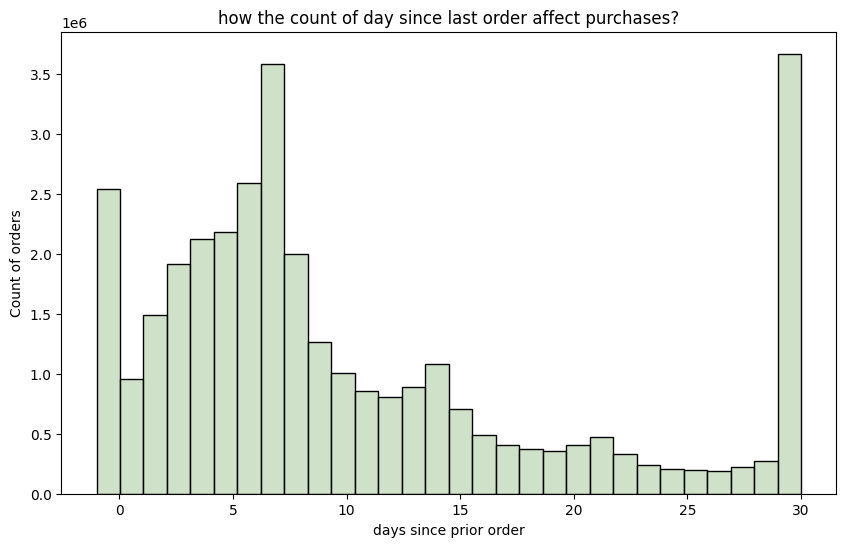

In [171]:
sns.histplot(data=data, x='days_since_prior_order', bins=30,color="#BFD8B8")
plt.xlabel('days since prior order')
plt.ylabel('Count of orders')
plt.title('how the count of day since last order affect purchases?')
plt.show()

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/2976742786.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  first_product_freq_desc = first_order_product.groupby(['product_name'], as_index = False)['order_id'].count().sort_values(by=['order_id'], ascending=False)


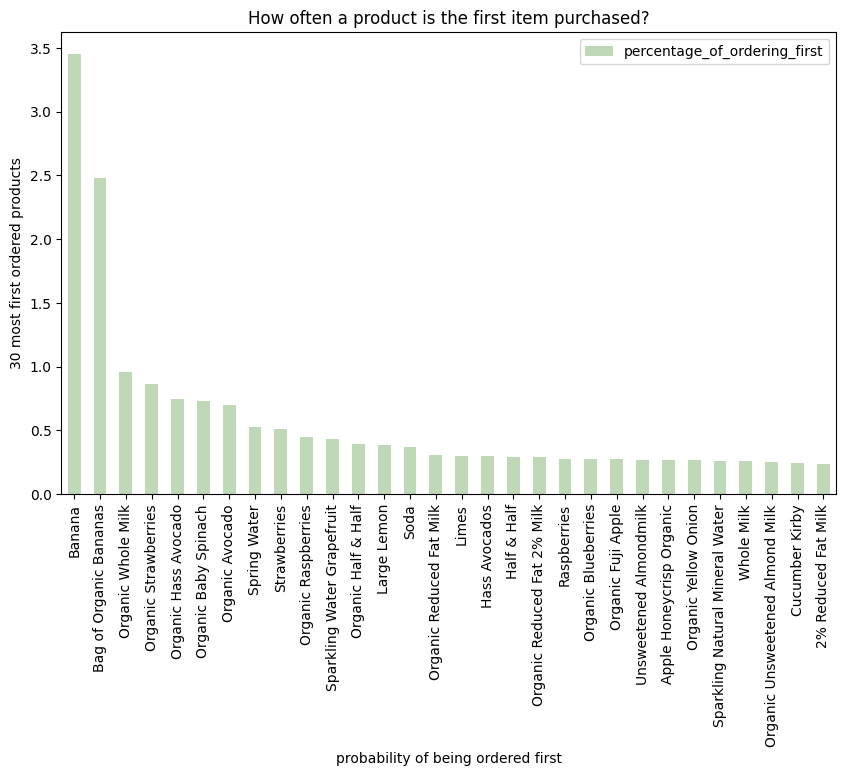

In [172]:
# Sorting Products by the count of times they appeared first in cart.
total_orders = data['order_id'].nunique()
first_order_product = data[data['add_to_cart_order'] == 1]
first_product_freq_desc = first_order_product.groupby(['product_name'], as_index = False)['order_id'].count().sort_values(by=['order_id'], ascending=False)
first_product_freq_desc['count_of_ordering_first'] = first_product_freq_desc['order_id']

# Ploting the Percentage of being ordered first for the 30 most first ordered products.
first_product_freq_desc['percentage_of_ordering_first'] = (first_product_freq_desc['count_of_ordering_first']/total_orders) * 100
first_product_freq_desc.iloc[:30].plot.bar(x='product_name', y='percentage_of_ordering_first',color="#BFD8B8")
plt.ylabel('30 most first ordered products')
plt.xlabel('probability of being ordered first')
plt.xticks(rotation=90)
plt.title('How often a product is the first item purchased?')
plt.show()

del first_order_product, first_product_freq_desc

# Customer Segmentation

In [173]:
import pandas as pd
user_features = data.groupby('user_id').agg({
    'days_since_prior_order': 'mean',
    'reordered': 'mean'
}).reset_index()

# Aggregate aisle preferences per user
user_aisle_stats = data.groupby(['user_id', 'aisle_id']).agg(
    total_orders=('order_id', 'count'),
    reorder_rate=('reordered', 'mean')
).reset_index()

# Find the most frequently ordered aisle per user
most_frequent_aisle = user_aisle_stats.loc[user_aisle_stats.groupby('user_id')['total_orders'].idxmax()]
most_frequent_aisle = most_frequent_aisle[['user_id', 'aisle_id', 'total_orders']]
most_frequent_aisle.rename(columns={'aisle_id': 'favorite_aisle', 'total_orders': 'favorite_aisle_orders'}, inplace=True)

aisle_diversity = data.groupby('user_id')['aisle_id'].nunique().reset_index()
aisle_diversity.rename(columns={'aisle_id': 'unique_aisles'}, inplace=True)

# Merge results
user_features = user_features.merge(most_frequent_aisle, on='user_id', how='left')
user_features = user_features.merge(aisle_diversity, on='user_id', how='left')
user_features=user_features.drop(columns=['favorite_aisle'],axis=1)
user_features.head()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
0,1,17.757143,0.728571,15,13
1,2,16.915930,0.464602,42,37
2,3,10.068182,0.625000,19,16
3,4,11.722222,0.055556,3,14
4,5,9.130435,0.391304,10,17


Cette partie permet de restructurer les données sous la forme d'une nouvelle DataFrame contenant les statistiques des clients (Moyenne des fréquences de commande, Taux de recommande, commandes effectuées au niveau des allées préférées, et la diversité des allées)

In [174]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_features.drop(columns=['user_id']))

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2D for visualization
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results into a DataFrame
user_features_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
user_features_pca['user_id'] = user_features['user_id']

Composante 1 : 54.27% de la variance expliquée
Composante 2 : 19.04% de la variance expliquée
Variance cumulée (2 composantes) : 73.31%


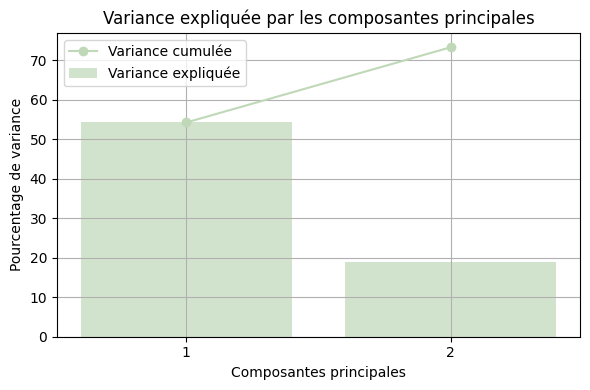

In [175]:
import matplotlib.pyplot as plt
import numpy as np

# Afficher les variances expliquées
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Affichage texte
for i, var in enumerate(explained_variance, start=1):
    print(f"Composante {i} : {var:.2%} de la variance expliquée")

print(f"Variance cumulée (2 composantes) : {cumulative_variance[1]:.2%}")

# Affichage graphique (scree plot)
plt.figure(figsize=(6, 4))
plt.bar(range(1, 3), explained_variance * 100, alpha=0.7, align='center', label='Variance expliquée',color="#BFD8B8")
plt.plot(range(1, 3), cumulative_variance * 100, marker='o', label='Variance cumulée',color="#BFD8B8")
plt.xticks([1, 2])
plt.ylabel("Pourcentage de variance")
plt.xlabel("Composantes principales")
plt.title("Variance expliquée par les composantes principales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Elbow Method for Optimal K')

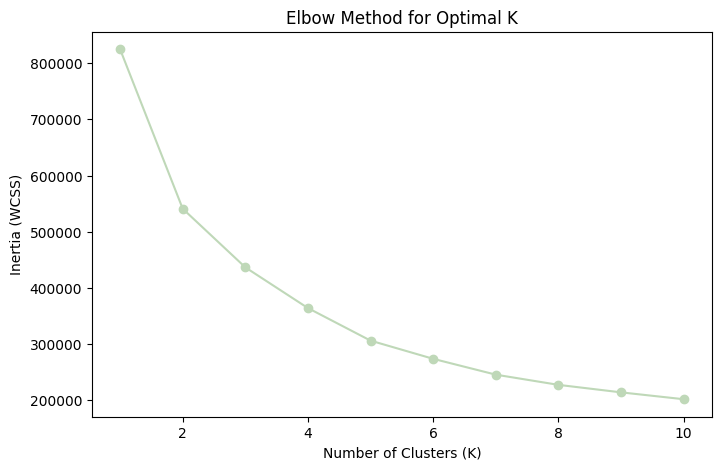

In [176]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
inertia = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) 

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-',color="#BFD8B8")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K")

Nous avons utilisé la méthode PCA (Reduction de dimension) ainsi que la méthode KMeans (Pour le Clustering) afin de ségmenter la clientèle. Cependant, afin de déterminer le nombre optimal de clusters, nous avons opté pour la méthode du coude qui nous a amené à un nombre optimal de 3.

/var/folders/_j/yqtls3w13gbg4tfd7g2xq1h40000gp/T/ipykernel_2227/2051301796.py:9: UserWarning: The palette list has more values (33819106) than needed (3), which may not be intended.
  sns.scatterplot(x=user_features_pca['PC1'], y=user_features_pca['PC2'], hue=user_features_pca['Cluster'], palette=colors)


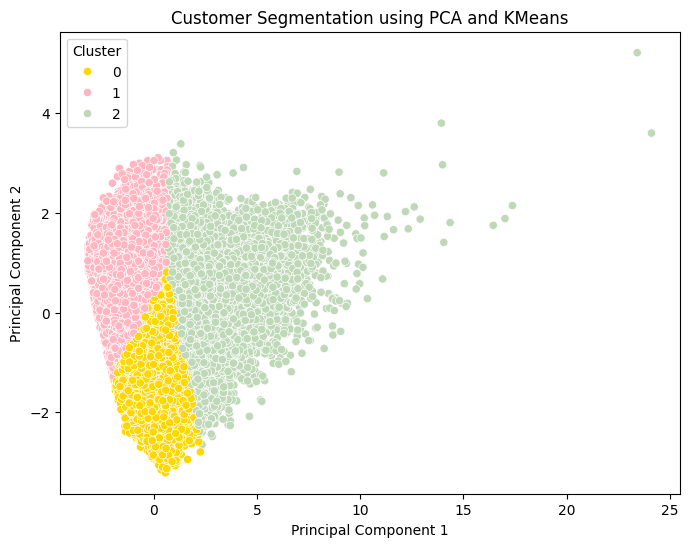

In [177]:
kmeans = KMeans(n_clusters=3, random_state=42)  
user_features_pca['Cluster'] = kmeans.fit_predict(X_pca)

# Visualize clusters
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=user_features_pca['PC1'], y=user_features_pca['PC2'], hue=user_features_pca['Cluster'], palette=colors)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segmentation using PCA and KMeans')
plt.legend(title='Cluster')
plt.show()

In [119]:
user_features_pca.head()

,PC1,PC2,user_id,Cluster
0,-0.301132,-0.387101,1,0
1,0.208951,0.825701,2,1
2,0.161966,-1.127450,3,0
3,-1.667789,-0.563290,4,1
4,-0.451895,-1.036327,5,0


In [120]:
cluster_1=user_features[user_features_pca['Cluster'] == 0]
cluster_2=user_features[user_features_pca['Cluster'] == 1]
cluster_3=user_features[user_features_pca['Cluster'] == 2]

Cette partie de code permet de récupérer les données propres à chaque segment de clientèle

In [121]:
cluster_1.describe()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
count,77984.000000,77984.000000,77984.000000,77984.000000,77984.000000
mean,102982.426023,10.024905,0.476682,19.420779,22.312872
std,59578.635161,3.775432,0.182737,13.883770,11.267252
min,1.000000,-0.576923,0.000000,1.000000,1.000000
25%,51258.000000,7.257110,0.350877,9.000000,13.000000
50%,103286.000000,10.000000,0.483660,16.000000,21.000000
75%,154393.250000,12.722222,0.607407,27.000000,30.000000
max,206207.000000,25.283186,0.981132,113.000000,63.000000


In [122]:
cluster_2.describe()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
count,86508.000000,86508.000000,86508.000000,86508.000000,86508.000000
mean,103329.994856,18.345345,0.312783,12.704524,24.501942
std,59518.993232,3.801416,0.154630,9.254352,12.190071
min,2.000000,6.263889,0.000000,1.000000,1.000000
25%,51996.000000,15.606061,0.200000,6.000000,15.000000
50%,103306.000000,18.233489,0.307692,10.000000,23.000000
75%,154972.500000,21.000000,0.421053,17.000000,33.000000
max,206209.000000,29.693069,0.909091,119.000000,82.000000


In [123]:
cluster_3.describe()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
count,41717.000000,41717.000000,41717.000000,41717.000000,41717.000000
mean,102867.565717,8.996808,0.656651,83.236834,49.384639
std,59449.564743,3.580671,0.124045,58.181061,13.566584
min,17.000000,0.264668,0.166065,10.000000,1.000000
25%,51359.000000,6.410920,0.572016,46.000000,41.000000
50%,102394.000000,8.520788,0.665072,68.000000,49.000000
75%,154442.000000,11.262687,0.749235,102.000000,58.000000
max,206208.000000,25.431137,0.989637,1540.000000,102.000000


In [124]:
# Fonction pour calculer Cohen's d (version adaptée à equal_var=False)
def cohens_d(group1, group2):
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)

    # Utilisation de l'écart-type moyen non pondéré
    s = np.sqrt((std1**2 + std2**2) / 2)
    d = (mean1 - mean2) / s
    return d

Les statistiques de base concernant les données propres à chaque segment

In [125]:
from scipy.stats import ttest_ind
t_stat1, p_value1 = ttest_ind(cluster_1['days_since_prior_order'], cluster_2['days_since_prior_order'], equal_var=False)
d1 = cohens_d(cluster_1['days_since_prior_order'], cluster_2['days_since_prior_order'])

# Comparaison cluster_2 vs cluster_3
t_stat2, p_value2 = ttest_ind(cluster_2['days_since_prior_order'], cluster_3['days_since_prior_order'], equal_var=False)
d2 = cohens_d(cluster_2['days_since_prior_order'], cluster_3['days_since_prior_order'])

# Comparaison cluster_3 vs cluster_1
t_stat3, p_value3 = ttest_ind(cluster_3['days_since_prior_order'], cluster_1['days_since_prior_order'], equal_var=False)
d3 = cohens_d(cluster_3['days_since_prior_order'], cluster_1['days_since_prior_order'])

# Affichage des résultats
print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}, Cohen's d_1: {d1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}, Cohen's d_2: {d2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}, Cohen's d_3: {d3}")

T-statistic_1: -444.8573972817549, P-value_1: 0.0, Cohen's d_1: -2.1962668895721436
T-statistic_2: 429.21909274986626, P-value_2: 0.0, Cohen's d_2: 2.531630516052246
T-statistic_3: -46.439139893437684, P-value_3: 0.0, Cohen's d_3: -0.2794243395328522


In [126]:
t_stat1, p_value1 = ttest_ind(cluster_1['unique_aisles'], cluster_2['unique_aisles'], equal_var=False)
d1 = cohens_d(cluster_1['unique_aisles'], cluster_2['unique_aisles'])

# Comparaison cluster_2 vs cluster_3
t_stat2, p_value2 = ttest_ind(cluster_2['unique_aisles'], cluster_3['unique_aisles'], equal_var=False)
d2 = cohens_d(cluster_2['unique_aisles'], cluster_3['unique_aisles'])

# Comparaison cluster_3 vs cluster_1
t_stat3, p_value3 = ttest_ind(cluster_3['unique_aisles'], cluster_1['unique_aisles'], equal_var=False)
d3 = cohens_d(cluster_3['unique_aisles'], cluster_1['unique_aisles'])

# Affichage des résultats
print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}, Cohen's d_1: {d1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}, Cohen's d_2: {d2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}, Cohen's d_3: {d3}")

T-statistic_1: -37.84597623707741, P-value_1: 0.0, Cohen's d_1: -0.1864985307629779
T-statistic_2: -317.81860170380946, P-value_2: 0.0, Cohen's d_2: -1.9293839529068053
T-statistic_3: 348.3406141273081, P-value_3: 0.0, Cohen's d_3: 2.1709468705703294


In [128]:
t_stat1, p_value1 = ttest_ind(cluster_1['favorite_aisle_orders'], cluster_2['favorite_aisle_orders'], equal_var=False)
d1 = cohens_d(cluster_1['favorite_aisle_orders'], cluster_2['favorite_aisle_orders'])

# Comparaison cluster_2 vs cluster_3
t_stat2, p_value2 = ttest_ind(cluster_2['favorite_aisle_orders'], cluster_3['favorite_aisle_orders'], equal_var=False)
d2 = cohens_d(cluster_2['favorite_aisle_orders'], cluster_3['favorite_aisle_orders'])

# Comparaison cluster_3 vs cluster_1
t_stat3, p_value3 = ttest_ind(cluster_3['favorite_aisle_orders'], cluster_1['favorite_aisle_orders'], equal_var=False)
d3 = cohens_d(cluster_3['favorite_aisle_orders'], cluster_1['favorite_aisle_orders'])

# Affichage des résultats
print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}, Cohen's d_1: {d1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}, Cohen's d_2: {d2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}, Cohen's d_3: {d3}")

T-statistic_1: 114.15041213845538, P-value_1: 0.0, Cohen's d_1: 0.5692536993648666
T-statistic_2: -246.11023615403994, P-value_2: 0.0, Cohen's d_2: -1.6931517401527418
T-statistic_3: 220.6931477257659, P-value_3: 0.0, Cohen's d_3: 1.5088192900257826


In [130]:
t_stat1, p_value1 = ttest_ind(cluster_1['reordered'], cluster_2['reordered'], equal_var=False)
d1 = cohens_d(cluster_1['reordered'], cluster_2['reordered'])

# Comparaison cluster_2 vs cluster_3
t_stat2, p_value2 = ttest_ind(cluster_2['reordered'], cluster_3['reordered'], equal_var=False)
d2 = cohens_d(cluster_2['reordered'], cluster_3['reordered'])

# Comparaison cluster_3 vs cluster_1
t_stat3, p_value3 = ttest_ind(cluster_3['reordered'], cluster_1['reordered'], equal_var=False)
d3 = cohens_d(cluster_3['reordered'], cluster_1['reordered'])

# Affichage des résultats
print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}, Cohen's d_1: {d1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}, Cohen's d_2: {d2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}, Cohen's d_3: {d3}")

T-statistic_1: 195.25656054244777, P-value_1: 0.0, Cohen's d_1: 0.9682806502159641
T-statistic_2: -428.0841864053145, P-value_2: 0.0, Cohen's d_2: -2.4531428564583004
T-statistic_3: 201.5833143334001, P-value_3: 0.0, Cohen's d_3: 1.1523676083183734


| **Variable**                | **Comparaison**        | **t-statistic** | **p-value** | **Cohen’s d** | **Interprétation de l'effet** |
|----------------------------|------------------------|----------------:|------------:|--------------:|-------------------------------|
| days_since_prior_order     | Cluster 1 vs Cluster 2 |     -444.86     |      0.0000 |        -2.20  | Très grande                   |
|                            | Cluster 2 vs Cluster 3 |      429.22     |      0.0000 |         2.53  | Très grande                   |
|                            | Cluster 3 vs Cluster 1 |      -46.44     |      0.0000 |        -0.28  | Petite                        |
| unique_aisles              | Cluster 1 vs Cluster 2 |      -37.85     |      0.0000 |        -0.19  | Négligeable                   |
|                            | Cluster 2 vs Cluster 3 |     -317.82     |      0.0000 |        -1.93  | Très grande                   |
|                            | Cluster 3 vs Cluster 1 |      348.34     |      0.0000 |         2.17  | Très grande                   |
| favorite_aisle_orders      | Cluster 1 vs Cluster 2 |      114.15     |      0.0000 |         0.57  | Moyenne                       |
|                            | Cluster 2 vs Cluster 3 |     -246.11     |      0.0000 |        -1.69  | Très grande                   |
|                            | Cluster 3 vs Cluster 1 |      220.69     |      0.0000 |         1.51  | Très grande                   |
| reordered                  | Cluster 1 vs Cluster 2 |      195.26     |      0.0000 |         0.97  | Grande                        |
|                            | Cluster 2 vs Cluster 3 |     -428.08     |      0.0000 |        -2.45  | Très grande                   |
|                            | Cluster 3 vs Cluster 1 |      201.58     |      0.0000 |         1.15  | Grande                        |

Après avoir segmenté la clientèle, nous avons évalué un ensemble de paramètres afin de nous assurer qu'il s'agit bien de segments cohérents et non de segments artificiellement imposés.

### Conclusion :
Le premier groupe représente les acheteurs occasionnels qui ont une certaine régularité dans leurs achats, mais explorent également différents produits. Le deuxième groupe représente les acheteurs occasionnels, moins fidèles, qui explorent différents produits. Ils peuvent acheter en gros ou de manière irrégulière. Le troisième groupe représente les acheteurs fréquents, qui ont des préférences marquées et commandent régulièrement leurs articles préférés ; il s'agit probablement de clients très engagés.